# Import Required Libraries

In [2]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Warnings
import warnings
warnings.filterwarnings('ignore')


# Load the Dataset

In [3]:
df = pd.read_excel('dermatology.xlsx')

# Check shape
print("Shape:", df.shape)

# Display first few rows
df.head()


Shape: (366, 35)


,Erythema,Scathing,Definite Borders,Itching,Koebner,Polygonal,Follicular,Oral,Knee,Scalp,...,Disapperance,Vacuolisation,Spongiosis,Retes,Follicular.1,Perifollicular,Inflamatory,Band-like,Age,Disease
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


# Handle Missing Values

In [24]:
# Check for any '?' values
df.replace('?', np.nan, inplace=True)

# Check missing values
df.isnull().sum()


Erythema            0
Scathing            0
Definite Borders    0
Itching             0
Koebner             0
Polygonal           0
Follicular          0
Oral                0
Knee                0
Scalp               0
Family Hostory      0
Melanin             0
Eosinophils         0
PNL                 0
Fibrosis            0
Exocytosis          0
Acanothosis         0
Hyperkeratosis      0
Parakeratosis       0
Clubbing            0
Elongation          0
Thinning            0
Spongiform          0
Munro               0
Focal               0
Disapperance        0
Vacuolisation       0
Spongiosis          0
Retes               0
Follicular.1        0
Perifollicular      0
Inflamatory         0
Band-like           0
Age                 8
Disease             0
dtype: int64

In [25]:
# Convert 'Age' to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Fill missing age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)


# Basic Exploration

In [27]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Class distribution
print("\nClass Distribution:")
print(df['Disease'].value_counts())

# Summary stats
df.describe().T


Shape of dataset: (366, 35)

Class Distribution:
Disease
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.0,3.0
Scathing,366.0,1.795082,0.701527,0.0,1.0,2.0,2.0,3.0
Definite Borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.0,3.0
Itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.0,3.0
Koebner,366.0,0.633880,0.908016,0.0,0.0,0.0,1.0,3.0
Polygonal,366.0,0.448087,0.957327,0.0,0.0,0.0,0.0,3.0
Follicular,366.0,0.166667,0.570588,0.0,0.0,0.0,0.0,3.0
Oral,366.0,0.377049,0.834147,0.0,0.0,0.0,0.0,3.0
Knee,366.0,0.614754,0.982979,0.0,0.0,0.0,1.0,3.0
Scalp,366.0,0.519126,0.905639,0.0,0.0,0.0,1.0,3.0


# Visualize Class Distribution


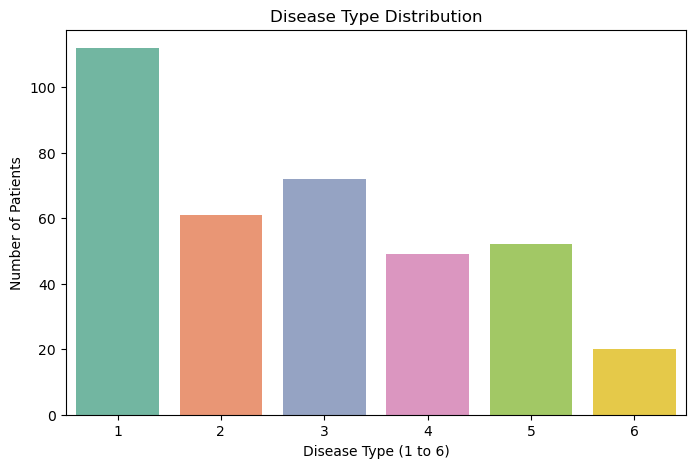

In [28]:
# Plot class distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Disease', data=df, palette='Set2')
plt.title("Disease Type Distribution")
plt.xlabel("Disease Type (1 to 6)")
plt.ylabel("Number of Patients")
plt.show()


# Model 1 — Regression Using Gradient Descent

## Gradient Descent Algorithm

In [29]:
# X = input feature (age), y = target (disease type)
X = df['Age'].values
y = df['Disease'].values

# Normalize X for better gradient descent performance
X = (X - X.mean()) / X.std()

# Initialize weights
m = 0  # slope
c = 0  # intercept
learning_rate = 0.01
epochs = 1000
n = float(len(X))  # number of samples

# Store MSE for each epoch
mse_list = []

# Gradient Descent Loop
for i in range(epochs):
    y_pred = m * X + c
    error = y - y_pred
    
    # Calculate gradients
    dm = (-2/n) * sum(X * error)
    dc = (-2/n) * sum(error)
    
    # Update parameters
    m = m - learning_rate * dm
    c = c - learning_rate * dc
    
    # Compute and store MSE
    mse = (error ** 2).mean()
    mse_list.append(mse)


## Plot Loss Curve

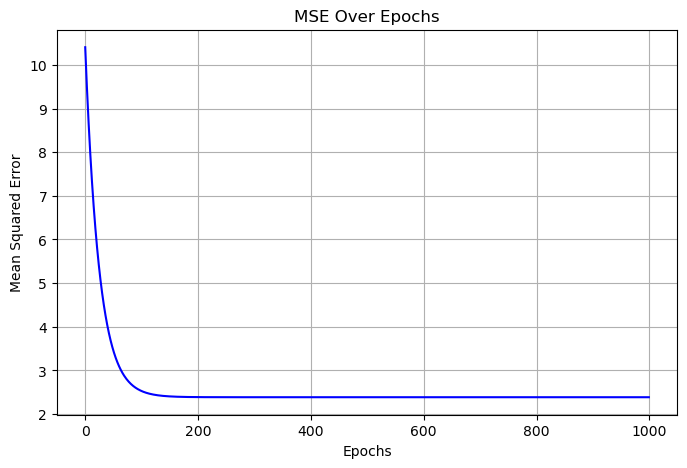

In [30]:
plt.figure(figsize=(8,5))
plt.plot(range(epochs), mse_list, color='blue')
plt.title("MSE Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.grid()
plt.show()


## Final Model Parameters

In [31]:
print("Final slope (m):", round(m, 4))
print("Final intercept (c):", round(c, 4))

# Predict a few values
y_pred_sample = m * X[:10] + c
print("Predicted disease types (first 10):", y_pred_sample.round(2))


Final slope (m): -0.4009
Final intercept (c): 2.8033
Predicted disease types (first 10): [2.31 3.55 3.08 2.7  2.57 2.68 3.29 2.25 3.18 2.97]


## Evaluation: MSE & Visualization

Final Mean Squared Error: 2.3853


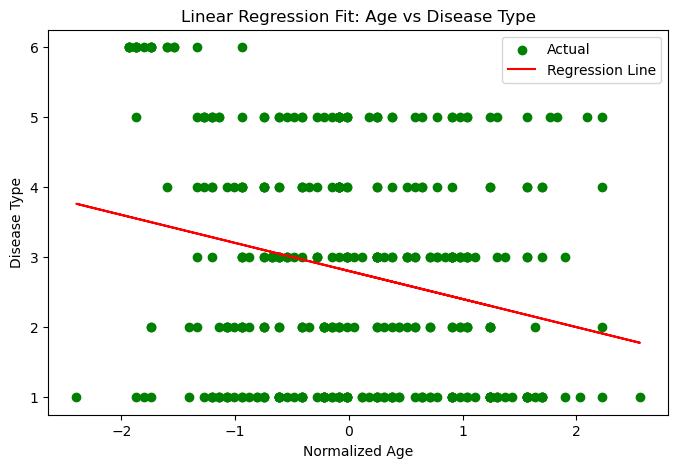

In [32]:
# Final MSE
final_mse = ((y - (m * X + c)) ** 2).mean()
print("Final Mean Squared Error:", round(final_mse, 4))

# Scatter plot of Age vs Disease Type with line of best fit
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='green', label='Actual')
plt.plot(X, m * X + c, color='red', label='Regression Line')
plt.title("Linear Regression Fit: Age vs Disease Type")
plt.xlabel("Normalized Age")
plt.ylabel("Disease Type")
plt.legend()
plt.show()


# Model 2 — Classification Using Random Forest


## Prepare the Data

In [33]:
# Feature set (X) and target (y)
X = df.drop("Disease", axis=1)
y = df["Disease"]

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Build & Train Random Forest Model

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Instantiate model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)


## Evaluate the Model

Random Forest Accuracy: 98.65 %

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74



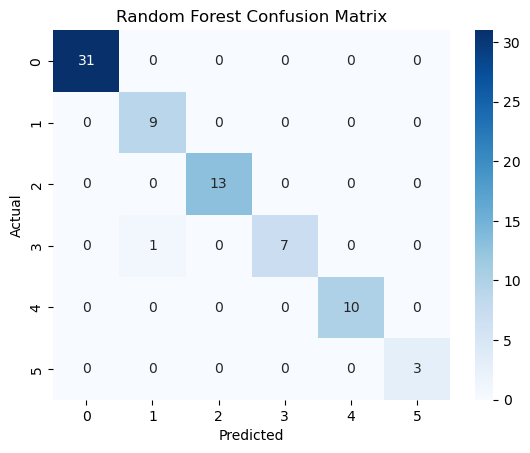

In [35]:
# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(acc_rf * 100, 2), "%")

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, cmap='Blues', fmt='g')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Feature Importance

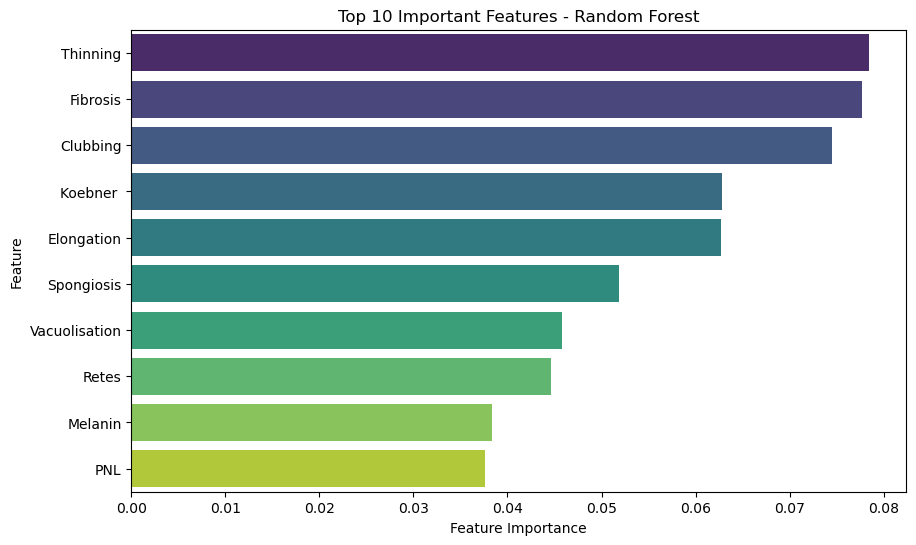

In [36]:
# Plot top features
importances = rf_model.feature_importances_
feat_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.show()


# Model 3 — Classification Using k-Nearest Neighbors (kNN)

## Train and Evaluate kNN Model (for different k values)

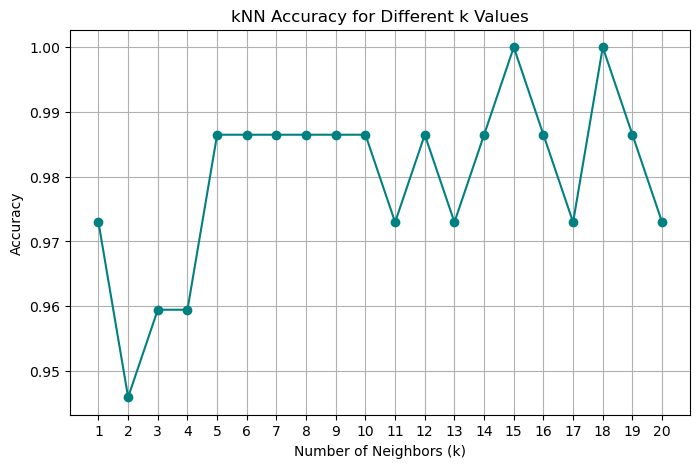

Best Accuracy: 100.0% at k = 15


In [37]:
from sklearn.neighbors import KNeighborsClassifier

# Try different k values and track performance
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_knn)
    accuracy_scores.append(acc)

# Plot accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='-', color='teal')
plt.title("kNN Accuracy for Different k Values")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid()
plt.show()

# Best k and corresponding accuracy
best_k = k_values[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)
print(f"Best Accuracy: {round(best_accuracy*100, 2)}% at k = {best_k}")


## Final Evaluation with Best k

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74



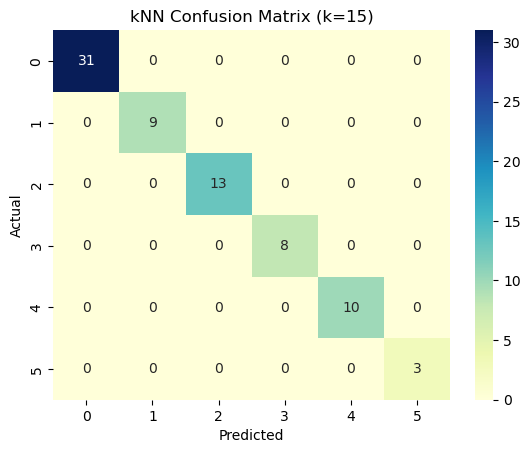

In [38]:
# Final kNN model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final_knn = knn_final.predict(X_test_scaled)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_final_knn))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_final_knn), annot=True, cmap="YlGnBu", fmt='g')
plt.title(f"kNN Confusion Matrix (k={best_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Model 4 & Model 5 — Clustering (K-Means & Agglomerative)

## Prepare Data for Clustering

In [39]:
# We'll use the same scaled features
from sklearn.metrics import adjusted_rand_score
X_scaled = scaler.fit_transform(X)  # X from earlier steps
true_labels = y.values


## K-Means Clustering (Model 4)

In [40]:
from sklearn.cluster import KMeans

# Apply KMeans with 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate clustering
ari_kmeans = adjusted_rand_score(true_labels, kmeans_labels)
print("Adjusted Rand Index (K-Means):", round(ari_kmeans, 4))


Adjusted Rand Index (K-Means): 0.6983


## Visualize K-Means Clustering (PCA Projection)

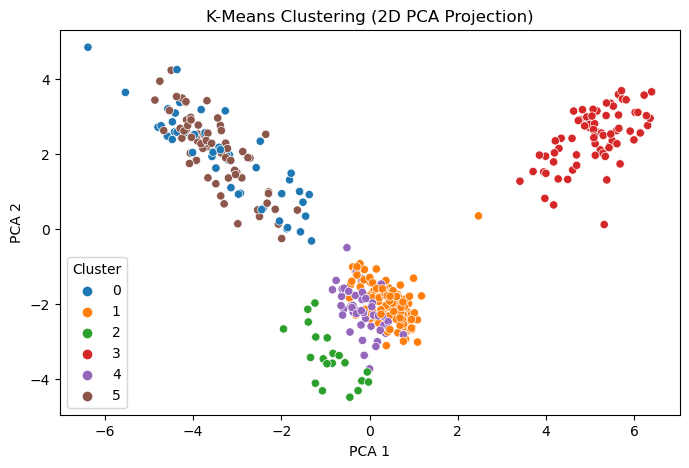

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette="tab10", legend='full')
plt.title("K-Means Clustering (2D PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()


## Agglomerative Clustering (Model 5)

In [42]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=6)
agglo_labels = agglo.fit_predict(X_scaled)

# Evaluate clustering
ari_agglo = adjusted_rand_score(true_labels, agglo_labels)
print("Adjusted Rand Index (Agglomerative):", round(ari_agglo, 4))


Adjusted Rand Index (Agglomerative): 0.9023


## Visualize Agglomerative Clustering

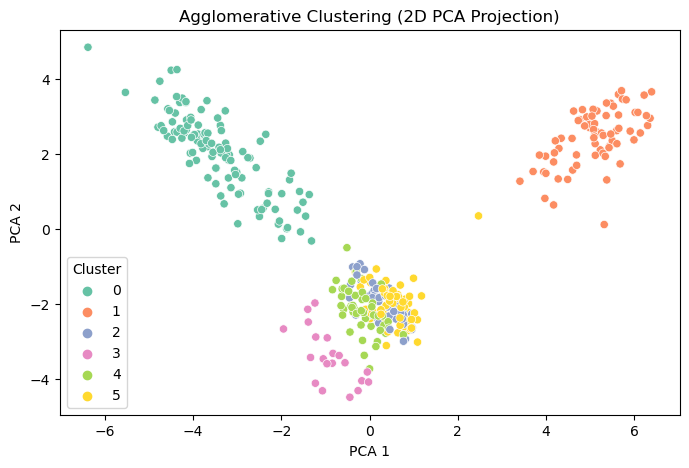

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=agglo_labels, palette="Set2", legend='full')
plt.title("Agglomerative Clustering (2D PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()
